# 02 — Backbone y Clasificacion

**Objetivo de este notebook**

Entrenar una red DenseNet121 para clasificar radiografias de torax como normales o anomalas.
El modelo entrenado aqui se guarda en Drive y es reutilizado por los notebooks 03 (regresion de edad)
y 04 (clustering por embeddings). Es el punto de partida de toda la cadena de experimentos.

**Datasets utilizados**
- NIH Chest X-Rays: backbone principal, solo vistas PA (posteroanterior), con patient-level split
- Chest X-Ray Pneumonia: validacion externa del modelo entrenado

**Archivos que produce este notebook**
- `Vena/checkpoints/mejor_modelo_clasificacion.h5` — modelo completo (backbone + cabeza), el mejor segun val_loss
- `Vena/checkpoints/backbone_densenet121.h5` — solo el backbone sin cabeza, para reutilizar en NB03 y NB04

**Prerequisito**
Haber ejecutado `01_Master_CSV.ipynb` al menos una vez para que exista `master.csv` en Drive.

---

**Instrucciones antes de ejecutar**

1. En el menu superior de Colab: `Entorno de ejecucion > Cambiar tipo de entorno de ejecucion`
2. Seleccionar `GPU` en el campo Acelerador de hardware
3. Guardar y luego ejecutar las celdas en orden de arriba hacia abajo
4. La primera vez que se ejecuta, la copia de imagenes a disco local tarda entre 5 y 20 minutos
   dependiendo de cuantas imagenes se seleccionen. Las siguientes ejecuciones en la misma sesion
   no necesitan repetir ese paso si la carpeta local ya existe.

## Celda 1 — Verificacion de GPU

Lo primero que se hace en cada sesion es confirmar que Colab asigno una GPU.
Si esta celda muestra 'No se encontro GPU', detener aqui y cambiar el tipo de entorno
de ejecucion antes de continuar. Entrenar en CPU es entre 10 y 50 veces mas lento
y la sesion de Colab se agotara antes de terminar un solo epoch.

In [1]:
import tensorflow as tf

# Listar los dispositivos fisicos disponibles de tipo GPU
gpus_disponibles = tf.config.list_physical_devices('GPU')

if gpus_disponibles:
    print(f"GPU encontrada: {gpus_disponibles[0].name}")
    print("El entrenamiento usara aceleracion por GPU.")
else:
    print("No se encontro GPU.")
    print("Ir a: Entorno de ejecucion > Cambiar tipo de entorno > GPU")
    print("Detener la ejecucion hasta resolver esto.")

GPU encontrada: /physical_device:GPU:0
El entrenamiento usara aceleracion por GPU.


## Celda 2 — Montar Google Drive

Colab corre en una maquina virtual en la nube que no tiene acceso a Drive por defecto.
Esta celda conecta esa maquina virtual con tu Drive para que podamos leer los datasets
y escribir los checkpoints del modelo.

Al ejecutar aparecera un dialogo pidiendo permiso. Aceptar con la cuenta que tiene acceso
a la carpeta compartida Vena.

La variable `ruta_vena` es el punto de entrada a toda la estructura de carpetas del proyecto.
Todas las rutas de este notebook se construyen a partir de ella, igual que en el NB01,
para que el codigo funcione identico en las tres computadoras del equipo.

In [3]:
from google.colab import drive
from pathlib import Path

# Montar Drive en la ruta estandar de Colab
drive.mount("/content/drive")

# Raiz del proyecto — igual en las tres computadoras del equipo
ruta_vena     = Path("/content/drive/MyDrive/Vena")
ruta_datasets = ruta_vena / "Notebooks" / "Datasets"

# Rutas especificas de cada dataset
ruta_nih      = ruta_datasets / "dataset_nih_resized" / "nih_resized_224"
ruta_nih_csv  = ruta_datasets / "dataset_nih_resized" / "Data_Entry_2017.csv"
ruta_chest    = ruta_datasets / "dataset_chest_xray" / "chest_xray"

# Carpeta donde se guardaran los checkpoints del modelo
# Se crea si no existe para que no haya error al guardar
ruta_checkpoints = ruta_vena / "checkpoints"
ruta_checkpoints.mkdir(parents=True, exist_ok=True)

# Ruta del master.csv generado por el notebook 01
ruta_master_csv = ruta_vena / "Notebooks" / "Datasets" / "master.csv"

# Verificar que los archivos criticos existen antes de continuar
assert ruta_master_csv.exists(), f"No se encontro master.csv en {ruta_master_csv}. Ejecutar primero el NB01."
assert ruta_nih_csv.exists(),    f"No se encontro Data_Entry_2017.csv en {ruta_nih_csv}."

print("Drive montado correctamente.")
print(f"Carpeta de checkpoints: {ruta_checkpoints}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado correctamente.
Carpeta de checkpoints: /content/drive/MyDrive/Vena/checkpoints


## Celda 3 — Importaciones y parametros de configuracion

Todos los hiperparametros del experimento se definen en un solo lugar aqui arriba.
Esto facilita hacer experimentos: si quieren probar con mas imagenes o diferente
learning rate, solo cambian este bloque y vuelven a ejecutar sin buscar numeros
dispersos a lo largo del notebook.

**Parametros importantes a entender:**

- `TAMANO_IMAGEN`: DenseNet121 fue disenado para imagenes de 224x224. Nuestras imagenes
  del NIH ya estan en ese tamano. No cambiar este valor.

- `BATCH_SIZE`: cuantas imagenes se procesan juntas antes de actualizar los pesos.
  Con DenseNet121 en la GPU T4 de Colab gratuito, 16 es el valor seguro. Con 32
  puede aparecer el error 'Out of Memory' (OOM). Si eso ocurre, reducir a 8.

- `IMAGENES_NIH_TRAIN`: cuantas imagenes del NIH se usan para entrenar. Empezamos
  con 20000 para que el entrenamiento quepa en una sesion de Colab. Se pueden subir
  a 40000 o mas si se tienen credenciales de Colab Pro.

- `EPOCHS_FASE_1` y `EPOCHS_FASE_2`: el entrenamiento ocurre en dos fases.
  Fase 1: backbone congelado, solo se entrena la cabeza nueva (rapido, estabiliza).
  Fase 2: se descongela la parte final del backbone para especializarlo en radiografias.

- `SEMILLA`: numero fijo para todas las operaciones aleatorias. Garantiza que el
  patient-level split sea identico si se vuelve a ejecutar el notebook. Importante
  para reproducibilidad del experimento.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import os
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Parametros del experimento ---

TAMANO_IMAGEN      = 224       # Pixeles. DenseNet121 espera 224x224. No cambiar.
BATCH_SIZE         = 16        # Imagenes por batch. Reducir a 8 si aparece error OOM.
EPOCHS_FASE_1      = 10        # Epochs con backbone congelado
EPOCHS_FASE_2      = 15        # Epochs con backbone descongelado (fine-tuning)
CAPAS_DESCONGELAR  = 50        # Cuantas capas finales del backbone se descongelan en fase 2
LR_FASE_1          = 1e-3      # Learning rate fase 1 (mas alto, entrena solo la cabeza)
LR_FASE_2          = 1e-5      # Learning rate fase 2 (muy bajo, no destruye pesos pre-entrenados)
IMAGENES_NIH_TRAIN = 20000     # Total de imagenes NIH para entrenamiento (balanceadas 50/50)
PACIENCIA_EARLY    = 5         # Epochs sin mejora antes de detener
SEMILLA            = 42        # Semilla para reproducibilidad de splits aleatorios

# Ruta local dentro de Colab donde se copiaran las imagenes para lectura rapida
# Esta carpeta es temporal: desaparece al cerrar la sesion de Colab
# Los checkpoints del modelo si se guardan en Drive y persisten
RUTA_LOCAL_IMGS    = Path("/content/imagenes_entrenamiento")

# Fijar la semilla global para numpy y tensorflow
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("Configuracion cargada correctamente.")
print(f"  Tamano de imagen  : {TAMANO_IMAGEN}x{TAMANO_IMAGEN} px")
print(f"  Batch size        : {BATCH_SIZE}")
print(f"  Imagenes NIH train: {IMAGENES_NIH_TRAIN:,}")
print(f"  Epochs fase 1     : {EPOCHS_FASE_1}")
print(f"  Epochs fase 2     : {EPOCHS_FASE_2}")

Configuracion cargada correctamente.
  Tamano de imagen  : 224x224 px
  Batch size        : 16
  Imagenes NIH train: 20,000
  Epochs fase 1     : 10
  Epochs fase 2     : 15


## Celda 4 — Cargar master.csv y agregar metadata del NIH

El master.csv generado por NB01 tiene tres columnas: ruta_completa, tiene_anomalia y fuente.
Para este notebook necesitamos dos columnas adicionales que solo existen en el CSV original del NIH:

- `Patient ID`: necesario para hacer el patient-level split (que un paciente no aparezca
  en train y test al mismo tiempo)
- `Patient Age`: necesario para el notebook 03 de regresion. Lo traemos aqui desde el inicio
  para no tener que hacer otro join mas adelante.
- `View Position`: para filtrar y quedarnos SOLO con vistas PA (posteroanterior, la vista
  frontal estandar). Las vistas AP (pacientes encamados) y laterales tienen peor calidad
  diagnostica y pueden confundir al modelo.

La operacion pd.merge() combina dos tablas por una columna en comun, igual que un JOIN
en SQL. Aqui unimos master.csv con Data_Entry_2017.csv usando el nombre del archivo
de imagen como llave.

In [5]:
# Cargar el master.csv unificado
df_master = pd.read_csv(ruta_master_csv)
print(f"Master CSV cargado: {len(df_master):,} filas totales")

# Cargar la metadata original del NIH que tiene Patient ID, edad y vista
df_nih_meta = pd.read_csv(ruta_nih_csv)
print(f"Metadata NIH cargada: {len(df_nih_meta):,} entradas")

# Separar solo las filas del NIH del master
df_nih = df_master[df_master["fuente"] == "nih"].copy()

# Extraer el nombre del archivo de la ruta completa para usarlo como llave del join
# Ejemplo: '/content/drive/.../00001234_001.png' -> '00001234_001.png'
df_nih["nombre_imagen"] = df_nih["ruta_completa"].apply(lambda x: Path(x).name)

# Hacer el join con la metadata del NIH
# Solo traemos las columnas que necesitamos para no inflar el DataFrame
columnas_meta = ["Image Index", "Patient ID", "Patient Age", "View Position"]
df_nih = df_nih.merge(
    df_nih_meta[columnas_meta],
    left_on="nombre_imagen",
    right_on="Image Index",
    how="inner"  # solo conservar filas que tengan coincidencia en ambos lados
)

print(f"\nNIH antes de filtrar por vista: {len(df_nih):,} imagenes")
print("Distribucion por tipo de vista:")
print(df_nih["View Position"].value_counts().to_string())

# Filtrar: conservar SOLO vistas PA (posteroanterior)
# PA es la radiografia frontal estandar tomada con el paciente de pie
# AP se toma con el paciente acostado y tiene peor definicion anatomica
# Las vistas laterales muestran el torax de perfil y son un tipo de imagen diferente
df_nih_pa = df_nih[df_nih["View Position"] == "PA"].copy()

print(f"\nNIH solo vistas PA: {len(df_nih_pa):,} imagenes")
print(f"  Con anomalia : {df_nih_pa['tiene_anomalia'].sum():,}")
print(f"  Sin anomalia : {(df_nih_pa['tiene_anomalia'] == 0).sum():,}")

Master CSV cargado: 309,205 filas totales
Metadata NIH cargada: 112,120 entradas

NIH antes de filtrar por vista: 112,120 imagenes
Distribucion por tipo de vista:
View Position
PA    67310
AP    44810

NIH solo vistas PA: 67,310 imagenes
  Con anomalia : 28,008
  Sin anomalia : 39,302


## Celda 5 — Patient-level split del NIH

Este es uno de los pasos mas importantes del notebook y el que mas frecuentemente
se omite por error en proyectos con este dataset.

El NIH tiene ~30,000 pacientes unicos pero 112,120 imagenes. Muchos pacientes tienen
varias radiografias tomadas en distintas fechas. Si dividimos los datos imagen por imagen
de forma aleatoria, es muy probable que fotos del mismo paciente aparezcan tanto en
entrenamiento como en test. El modelo entonces 'reconoce' al paciente por rasgos
individuales (forma de costillas, densidad osea) y reporta metricas infladas que no
representan su capacidad real con pacientes nuevos.

La solucion es dividir por Patient ID. Todos los radiografias de un paciente van al
mismo conjunto. Primero dividimos los IDs unicos, y las imagenes se 'arrastran'
con su paciente automaticamente al filtrar con isin().

Proporciones usadas: 70% train, 15% validacion, 15% test.
Esto se hace en dos pasos: primero separar test, luego dividir el resto en train/val.

In [6]:
# Obtener los IDs unicos de pacientes del conjunto PA
pacientes_unicos = df_nih_pa["Patient ID"].unique()
print(f"Pacientes unicos en el NIH (solo PA): {len(pacientes_unicos):,}")

# Paso 1: separar el 15% para test
# La division se hace sobre los IDs de pacientes, no sobre las imagenes
pacientes_train_val, pacientes_test = train_test_split(
    pacientes_unicos,
    test_size=0.15,
    random_state=SEMILLA
)

# Paso 2: del restante 85%, separar el 15/85 = ~17.6% para validacion
# Esto resulta en aproximadamente 70% train, 15% val, 15% test
pacientes_train, pacientes_val = train_test_split(
    pacientes_train_val,
    test_size=0.176,
    random_state=SEMILLA
)

# Filtrar el DataFrame usando los IDs de cada conjunto
# isin() devuelve True para las filas cuyo Patient ID esta en la lista
df_train_completo = df_nih_pa[df_nih_pa["Patient ID"].isin(pacientes_train)].copy()
df_val            = df_nih_pa[df_nih_pa["Patient ID"].isin(pacientes_val)].copy()
df_test_nih       = df_nih_pa[df_nih_pa["Patient ID"].isin(pacientes_test)].copy()

# Verificar que no hay filtracion entre conjuntos (ningun Patient ID aparece en dos)
ids_train = set(df_train_completo["Patient ID"])
ids_val   = set(df_val["Patient ID"])
ids_test  = set(df_test_nih["Patient ID"])

assert len(ids_train & ids_val)  == 0, "Hay pacientes compartidos entre train y val"
assert len(ids_train & ids_test) == 0, "Hay pacientes compartidos entre train y test"
assert len(ids_val   & ids_test) == 0, "Hay pacientes compartidos entre val y test"

print(f"\nSplit por paciente completado sin filtracion:")
print(f"  Train : {len(df_train_completo):,} imagenes ({len(pacientes_train):,} pacientes)")
print(f"  Val   : {len(df_val):,} imagenes ({len(pacientes_val):,} pacientes)")
print(f"  Test  : {len(df_test_nih):,} imagenes ({len(pacientes_test):,} pacientes)")

Pacientes unicos en el NIH (solo PA): 28,868

Split por paciente completado sin filtracion:
  Train : 47,267 imagenes (20,218 pacientes)
  Val   : 9,863 imagenes (4,319 pacientes)
  Test  : 10,180 imagenes (4,331 pacientes)


## Celda 6 — Subsampling balanceado del conjunto de entrenamiento

El conjunto de train del NIH tiene muchas mas imagenes con anomalia que sin anomalia.
Si entrenamos con ese desbalance, el modelo aprende a predecir siempre 'tiene anomalia'
porque eso le da alta exactitud sin aprender nada real.

La solucion mas simple para este experimento inicial es tomar la misma cantidad de
imagenes de cada clase (50% anomalia, 50% normal). Esto se llama undersampling de
la clase mayoritaria.

El parametro IMAGENES_NIH_TRAIN controla el total. Con 20000 tomamos 10000 de cada clase.
Este numero puede subirse si se tiene Colab Pro o si se quiere un segundo experimento
con mas datos.

In [7]:
imagenes_por_clase = IMAGENES_NIH_TRAIN // 2

# Separar por clase dentro del conjunto de train
df_train_anomalia = df_train_completo[df_train_completo["tiene_anomalia"] == 1]
df_train_normal   = df_train_completo[df_train_completo["tiene_anomalia"] == 0]

print(f"Imagenes disponibles en train antes de subsampling:")
print(f"  Con anomalia : {len(df_train_anomalia):,}")
print(f"  Sin anomalia : {len(df_train_normal):,}")

# Verificar que hay suficientes imagenes de cada clase
assert len(df_train_anomalia) >= imagenes_por_clase, (
    f"No hay suficientes imagenes con anomalia. "
    f"Disponibles: {len(df_train_anomalia)}, necesarias: {imagenes_por_clase}"
)
assert len(df_train_normal) >= imagenes_por_clase, (
    f"No hay suficientes imagenes normales. "
    f"Disponibles: {len(df_train_normal)}, necesarias: {imagenes_por_clase}"
)

# Tomar una muestra aleatoria de cada clase
muestra_anomalia = df_train_anomalia.sample(n=imagenes_por_clase, random_state=SEMILLA)
muestra_normal   = df_train_normal.sample(n=imagenes_por_clase, random_state=SEMILLA)

# Combinar y mezclar las dos clases
df_train = pd.concat([muestra_anomalia, muestra_normal]).sample(
    frac=1.0, random_state=SEMILLA
).reset_index(drop=True)

print(f"\nSubmuestra de entrenamiento final:")
print(f"  Total        : {len(df_train):,} imagenes")
print(f"  Con anomalia : {df_train['tiene_anomalia'].sum():,} (50%)")
print(f"  Sin anomalia : {(df_train['tiene_anomalia'] == 0).sum():,} (50%)")

Imagenes disponibles en train antes de subsampling:
  Con anomalia : 19,637
  Sin anomalia : 27,630

Submuestra de entrenamiento final:
  Total        : 20,000 imagenes
  Con anomalia : 10,000 (50%)
  Sin anomalia : 10,000 (50%)


## Celda 7 — Copiar imagenes al disco local de Colab

Google Drive esta montado como un sistema de archivos en red. Cada vez que el
DataLoader pide una imagen durante el entrenamiento, Colab hace una peticion de
red a Drive, descarga el archivo y lo manda a la GPU. Con decenas de miles de
imagenes por epoch, este trafico de red se convierte en el cuello de botella
principal y la GPU queda ociosa esperando datos la mayor parte del tiempo.

La solucion es copiar las imagenes al disco local de la maquina virtual de Colab
(/content/) antes de empezar el entrenamiento. Una vez copiadas, el DataLoader
lee desde disco local sin ningun trafico de red y la GPU trabaja a capacidad.

Por que xargs en lugar de un loop de Python:
Copiar archivo por archivo desde Python (shutil.copy en un for loop) hace una
llamada al sistema operativo por cada imagen, lo cual es muy lento con Drive.
xargs ejecuta multiples procesos cp en paralelo usando todos los nucleos de CPU
disponibles en la VM de Colab, reduciendo el tiempo de copia de horas a minutos.

Importante: /content/ es temporal. Al cerrar la sesion de Colab desaparece.
Los checkpoints del modelo se guardan en Drive y persisten entre sesiones.
Si se vuelve a abrir una sesion nueva, hay que volver a ejecutar esta celda.

Tiempo estimado: 8 a 15 minutos para 20,000 imagenes. Para 10,000 imagenes
es aproximadamente la mitad. Si el tiempo sigue siendo inaceptable, reducir
IMAGENES_NIH_TRAIN a 10000 en la celda 3 y volver a ejecutar desde la celda 6.

In [8]:
import subprocess
import time
from pathlib import Path

# --- Descomprimir NIH ---

ruta_zip_nih      = "/content/drive/MyDrive/Vena/Notebooks/Datasets/nih_resized_224.zip"
ruta_destino_nih  = Path("/content/nih_resized_224")

assert Path(ruta_zip_nih).exists(), (
    "El zip del NIH no se encuentra en Drive todavia.\n"
    "Esperar a que termine la subida antes de continuar."
)

n_existentes_nih = (
    len(list(ruta_destino_nih.glob("*.png")))
    if ruta_destino_nih.exists() else 0
)

if n_existentes_nih > 1000:
    print(f"NIH ya en disco local: {n_existentes_nih:,} imagenes. Saltando.")
else:
    print("Descomprimiendo NIH...")
    inicio = time.time()
    subprocess.run(
        f"unzip -q {ruta_zip_nih} -d /content/",
        shell=True
    )
    transcurrido = time.time() - inicio
    n = len(list(ruta_destino_nih.glob("*.png")))
    print(f"Completado en {transcurrido/60:.1f} minutos — {n:,} imagenes")

# --- Descomprimir Chest X-Ray ---

ruta_zip_chest    = "/content/drive/MyDrive/Vena/Notebooks/Datasets/chest_xray.zip"
ruta_destino_chest = Path("/content/chest_xray")

assert Path(ruta_zip_chest).exists(), (
    "El zip del Chest X-Ray no se encuentra en Drive todavia."
)

n_existentes_chest = (
    len(list(ruta_destino_chest.rglob("*.jpeg")))
    if ruta_destino_chest.exists() else 0
)

if n_existentes_chest > 100:
    print(f"Chest X-Ray ya en disco local: {n_existentes_chest:,} imagenes. Saltando.")
else:
    print("Descomprimiendo Chest X-Ray...")
    inicio = time.time()
    subprocess.run(
        f"unzip -q {ruta_zip_chest} -d /content/",
        shell=True
    )
    transcurrido = time.time() - inicio
    n = len(list(ruta_destino_chest.rglob("*.jpeg")))
    print(f"Completado en {transcurrido/60:.1f} minutos — {n:,} imagenes")

# --- Actualizar rutas del NIH en los DataFrames ---
# Las imagenes del NIH estan todas en la raiz de nih_resized_224/
# sin subcarpetas, asi que Path(ruta).name encuentra cada una directamente

RUTA_LOCAL_NIH = ruta_destino_nih

def actualizar_rutas_nih(df):
    df = df.copy()
    df["ruta_completa"] = df["ruta_completa"].apply(
        lambda ruta: str(RUTA_LOCAL_NIH / Path(ruta).name)
    )
    return df

df_train    = actualizar_rutas_nih(df_train)
df_val      = actualizar_rutas_nih(df_val)
df_test_nih = actualizar_rutas_nih(df_test_nih)

# --- Actualizar ruta_chest para que apunte al disco local ---
# La celda 8 usa ruta_chest para construir los DataFrames del Chest X-Ray
# Redirigirla al disco local evita que lea desde Drive durante el entrenamiento
ruta_chest = ruta_destino_chest

# Verificacion final
n_faltantes = sum(
    1 for r in df_train["ruta_completa"]
    if not Path(r).exists()
)

if n_faltantes > 0:
    print(f"Advertencia: {n_faltantes} imagenes de train no encontradas en disco local.")
else:
    print("Verificacion completada: todas las rutas apuntan a disco local.")

Descomprimiendo NIH...
Completado en 1.2 minutos — 112,120 imagenes
Descomprimiendo Chest X-Ray...
Completado en 0.6 minutos — 5,856 imagenes
Verificacion completada: todas las rutas apuntan a disco local.


## Celda 8 — Preparar el dataset de Chest X-Ray para validacion externa

El Chest X-Ray Pneumonia tiene su propio split ya definido (carpetas train/val/test).
Lo usaremos como validacion externa: entrenaremos con el NIH y al final evaluaremos
que tan bien el modelo generaliza a este dataset diferente.

Este dataset tiene un desbalance de clases: aproximadamente 74% de las imagenes
son de neumonia y 26% normales. Para el entrenamiento esto se corrige con pesos
de clase. Para la evaluacion lo medimos tal cual es.

Chest X-Ray no tiene metadata de edad, por eso no participa en el notebook 03.
Sus imagenes son JPG (el NIH son PNG), pero Keras las maneja igual.

In [9]:
def construir_df_chest(split):
    """
    Recorre las carpetas NORMAL y PNEUMONIA de un split del dataset Chest X-Ray
    y construye un DataFrame con ruta_completa y tiene_anomalia.
    """
    registros = []
    for clase, etiqueta in [("NORMAL", 0), ("PNEUMONIA", 1)]:
        carpeta = ruta_chest / split / clase
        if not carpeta.exists():
            print(f"  Advertencia: no se encontro la carpeta {carpeta}")
            continue
        for archivo in carpeta.iterdir():
            if archivo.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                registros.append({
                    "ruta_completa"  : str(archivo),
                    "tiene_anomalia" : etiqueta,
                    "fuente"         : "chest_xray"
                })
    return pd.DataFrame(registros)

df_chest_train = construir_df_chest("train")
df_chest_val   = construir_df_chest("val")
df_chest_test  = construir_df_chest("test")

print("Dataset Chest X-Ray Pneumonia:")
print(f"  Train : {len(df_chest_train):,} imagenes")
print(f"    Neumonia : {df_chest_train['tiene_anomalia'].sum():,}")
print(f"    Normal   : {(df_chest_train['tiene_anomalia']==0).sum():,}")
print(f"  Val   : {len(df_chest_val):,} imagenes")
print(f"  Test  : {len(df_chest_test):,} imagenes")

# Calcular pesos de clase para corregir el desbalance en el entrenamiento
# compute_class_weight asigna mas peso a la clase minoritaria automaticamente
clases        = np.array([0, 1])
pesos_clase   = compute_class_weight(
    class_weight="balanced",
    classes=clases,
    y=df_chest_train["tiene_anomalia"].values
)
dict_pesos    = {0: pesos_clase[0], 1: pesos_clase[1]}
print(f"\nPesos de clase para corregir desbalance:")
print(f"  Normal   (0): {dict_pesos[0]:.3f}")
print(f"  Neumonia (1): {dict_pesos[1]:.3f}")

Dataset Chest X-Ray Pneumonia:
  Train : 5,216 imagenes
    Neumonia : 3,875
    Normal   : 1,341
  Val   : 16 imagenes
  Test  : 624 imagenes

Pesos de clase para corregir desbalance:
  Normal   (0): 1.945
  Neumonia (1): 0.673


## Celda 9 — Generadores de datos (DataLoaders)

Un generador de datos es un objeto que le entrega imagenes al modelo en lotes
(batches) durante el entrenamiento. En lugar de cargar todas las imagenes en memoria
a la vez (lo que agotaria la RAM), el generador lee y preprocesa solo las imagenes
del batch actual.

El preprocesamiento que aplica DenseNet121 consiste en restar la media de ImageNet
a cada canal de color. Esto es necesario porque el modelo fue pre-entrenado con
imagenes normalizadas de esa forma, y si le damos pixeles en escala diferente los
pesos pre-entrenados no funcionan correctamente.

Data augmentation (solo en train): se aplican transformaciones aleatorias a las
imagenes para que el modelo vea variaciones y no memorice las imagenes de entrenamiento.
Las transformaciones elegidas son conservadoras para radiografias:
- Rotacion leve: una radiografia real puede estar ligeramente inclinada
- Zoom leve: diferentes distancias del equipo al paciente
- Flip horizontal: los pulmones son aproximadamente simetricos
NO se usa flip vertical porque una radiografia invertida verticalmente no existe
en la practica clinica y confundiria al modelo.

In [10]:
from tensorflow.keras.applications.densenet import preprocess_input

# Generador con augmentation para entrenamiento
generador_train = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # normalizacion especifica de DenseNet121
    rotation_range=10,      # rotar hasta 10 grados en cualquier direccion
    zoom_range=0.1,         # zoom de hasta 10%
    horizontal_flip=True,   # espejo horizontal (los pulmones son casi simetricos)
    fill_mode="nearest"     # al rotar, rellenar los bordes con el pixel mas cercano
)

# Generador sin augmentation para validacion y test
# En validacion y test queremos medir el rendimiento real, sin modificar las imagenes
generador_eval = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

def crear_flujo(generador, df, mezclar=True):
    """
    Crea un flujo de imagenes desde un DataFrame.
    flow_from_dataframe lee las imagenes usando la columna 'ruta_completa'
    y usa 'tiene_anomalia' como etiqueta.
    """
    return generador.flow_from_dataframe(
        dataframe=df,
        x_col="ruta_completa",      # columna con la ruta de cada imagen
        y_col="tiene_anomalia",     # columna con la etiqueta (0 o 1)
        target_size=(TAMANO_IMAGEN, TAMANO_IMAGEN),
        color_mode="rgb",           # DenseNet121 espera 3 canales aunque sea escala de grises
        class_mode="raw",           # etiquetas numericas directas, no categoricas
        batch_size=BATCH_SIZE,
        shuffle=mezclar,
        seed=SEMILLA
    )

# Crear los flujos de datos para cada conjunto
flujo_train     = crear_flujo(generador_train, df_train,        mezclar=True)
flujo_val       = crear_flujo(generador_eval,  df_val,          mezclar=False)
flujo_test_nih  = crear_flujo(generador_eval,  df_test_nih,     mezclar=False)
flujo_chest_val = crear_flujo(generador_eval,  df_chest_val,    mezclar=False)
flujo_chest_test= crear_flujo(generador_eval,  df_chest_test,   mezclar=False)

print("Generadores de datos creados.")
print(f"  Pasos por epoch en train : {len(flujo_train)}")
print(f"  Pasos por epoch en val   : {len(flujo_val)}")

Found 20000 validated image filenames.
Found 9863 validated image filenames.
Found 10180 validated image filenames.
Found 16 validated image filenames.
Found 624 validated image filenames.
Generadores de datos creados.
  Pasos por epoch en train : 1250
  Pasos por epoch en val   : 617


## Celda 10 — Definir el modelo DenseNet121

La arquitectura tiene dos partes:

1. Backbone (DenseNet121 pre-entrenado con ImageNet):
   Se carga sin la ultima capa (include_top=False) porque esa capa clasifica
   1000 categorias de ImageNet y no nos sirve. Los pesos pre-entrenados representan
   conocimiento sobre texturas, bordes y patrones que el modelo aprendio de millones
   de imagenes. Ese conocimiento se transfiere a nuestro problema de radiografias.

2. Cabeza de clasificacion (capas nuevas que agregamos):
   - GlobalAveragePooling2D: convierte el mapa de caracteristicas 3D en un vector 1D
     de 1024 dimensiones. Este vector es el 'embedding' que usara el notebook 04.
   - Dense(256, relu): capa completamente conectada para aprender combinaciones
     de las caracteristicas del backbone especificas para nuestro problema
   - Dropout(0.5): durante el entrenamiento, apaga aleatoriamente el 50% de las
     neuronas en cada paso. Esto previene que el modelo memorice el training set
     (sobreajuste). Se desactiva automaticamente durante evaluacion.
   - Dense(1, sigmoid): neurona de salida. Sigmoid comprime el valor a [0,1],
     interpretable como probabilidad de anomalia.

En la Fase 1 el backbone se congela (trainable=False) para que sus pesos no
cambien mientras la cabeza nueva aprende desde cero.

In [ ]:
# Cargar DenseNet121 con pesos de ImageNet, sin la capa de clasificacion original
backbone = DenseNet121(
    weights="imagenet",        # pesos pre-entrenados con ImageNet
    include_top=False,         # excluir la cabeza original de 1000 clases
    input_shape=(TAMANO_IMAGEN, TAMANO_IMAGEN, 3)  # 3 canales RGB
)

# Congelar todos los pesos del backbone para la Fase 1
# trainable=False significa que estos pesos no se actualizaran durante el entrenamiento
backbone.trainable = False

# Construir la cabeza de clasificacion
x = backbone.output
x = GlobalAveragePooling2D(name="capa_pooling")(x)  # (batch, 7, 7, 1024) -> (batch, 1024)
x = Dense(256, activation="relu", name="capa_densa")(x)
x = Dropout(0.5, name="capa_dropout")(x)
salida = Dense(1, activation="sigmoid", name="capa_salida")(x)

# Crear el modelo completo uniendo backbone y cabeza
modelo = Model(inputs=backbone.input, outputs=salida, name="densenet121_clasificacion")

# Compilar el modelo para Fase 1
modelo.compile(
    optimizer=Adam(learning_rate=LR_FASE_1),
    loss="binary_crossentropy",  # funcion de perdida para clasificacion binaria
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# Contar parametros entrenables vs congelados
params_totales     = modelo.count_params()
params_entrenables = sum([tf.size(w).numpy() for w in modelo.trainable_weights])

print(f"Modelo definido: DenseNet121 + cabeza de clasificacion")
print(f"  Parametros totales      : {params_totales:,}")
print(f"  Parametros entrenables  : {params_entrenables:,} (solo cabeza, Fase 1)")
print(f"  Parametros congelados   : {params_totales - params_entrenables:,} (backbone)")

Modelo definido: DenseNet121 + cabeza de clasificacion
  Parametros totales      : 7,300,161
  Parametros entrenables  : 262,657 (solo cabeza, Fase 1)
  Parametros congelados   : 7,037,504 (backbone)


## Celda 11 — Definir callbacks

Los callbacks son funciones que Keras ejecuta automaticamente al final de cada epoch.
Se les pasa como lista al metodo fit() y corren en el orden en que aparecen.

Los tres callbacks que usamos:

1. ModelCheckpoint: guarda el modelo en Drive cada vez que val_loss mejora respecto
   al mejor valor visto hasta ese momento. Con save_best_only=True el archivo se
   sobreescribe solo cuando hay mejora, evitando que el Drive se llene de versiones.
   Esto significa que al terminar el entrenamiento, el archivo siempre contiene
   el mejor modelo encontrado, no necesariamente el del ultimo epoch.

2. EarlyStopping: si val_loss no mejora en 'paciencia' epochs consecutivos, detiene
   el entrenamiento. Previene desperdiciar tiempo en epochs que ya no aportan.
   restore_best_weights=True garantiza que al detenerse, el modelo en memoria tenga
   los pesos del mejor epoch, no del ultimo.

3. ReduceLROnPlateau: si val_loss no mejora en 3 epochs, divide el learning rate
   entre 10. Esto ayuda al modelo a salir de minimos locales donde los pasos grandes
   del optimizador ya no funcionan.

In [12]:
# Ruta donde se guarda el mejor modelo durante el entrenamiento
ruta_mejor_modelo = str(ruta_checkpoints / "mejor_modelo_clasificacion.h5")

callback_checkpoint = ModelCheckpoint(
    filepath=ruta_mejor_modelo,
    monitor="val_loss",       # metrica que determina si el modelo mejoro
    save_best_only=True,      # solo guardar si mejoro respecto al mejor anterior
    save_weights_only=False,  # guardar arquitectura y pesos (no solo pesos)
    mode="min",               # 'min' porque queremos que val_loss sea lo mas bajo posible
    verbose=1                 # imprimir mensaje cada vez que guarda
)

callback_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=PACIENCIA_EARLY,   # epochs sin mejora antes de detener
    restore_best_weights=True,  # al detenerse, usar los pesos del mejor epoch
    verbose=1
)

callback_reducir_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,        # nuevo_lr = lr_actual * 0.1
    patience=3,        # epochs sin mejora antes de reducir
    min_lr=1e-7,       # limite inferior del learning rate
    verbose=1
)

lista_callbacks = [callback_checkpoint, callback_early_stop, callback_reducir_lr]

print(f"Callbacks configurados.")
print(f"  Checkpoint guardara en: {ruta_mejor_modelo}")
print(f"  EarlyStopping: paciencia de {PACIENCIA_EARLY} epochs")

Callbacks configurados.
  Checkpoint guardara en: /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
  EarlyStopping: paciencia de 5 epochs


## Celda 12 — Fase 1: entrenar solo la cabeza

Con el backbone congelado, solo los pesos de la cabeza nueva se actualizan.
El objetivo de esta fase es estabilizar la cabeza antes de descongelar el backbone.

Si descongelamos el backbone desde el inicio con la cabeza inicializada aleatoriamente,
los gradientes grandes de esa cabeza pueden 'destruir' los pesos pre-entrenados
antes de que aprendan algo util para radiografias.

Historia de entrenamiento: el objeto 'historia_fase1' que devuelve fit() contiene
los valores de loss, accuracy y AUC por epoch. Lo guardamos para graficar despues.

In [ ]:
print("Iniciando Fase 1: entrenando solo la cabeza (backbone congelado)")
print(f"Epochs: {EPOCHS_FASE_1} | Learning rate: {LR_FASE_1}")
print()

historia_fase1 = modelo.fit(
    flujo_train,
    epochs=EPOCHS_FASE_1,
    validation_data=flujo_val,
    callbacks=lista_callbacks,
    verbose=1  # mostrar barra de progreso por epoch
)

print()
print("Fase 1 completada.")
print(f"Mejor val_loss: {min(historia_fase1.history['val_loss']):.4f}")

Iniciando Fase 1: entrenando solo la cabeza (backbone congelado)
Epochs: 10 | Learning rate: 0.001

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.5940 - auc: 0.6226 - loss: 0.6946
Epoch 1: val_loss improved from None to 0.63290, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 393s 289ms/step - accuracy: 0.6122 - auc: 0.6464 - loss: 0.6652 - val_accuracy: 0.6599 - val_auc: 0.6945 - val_loss: 0.6329 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6338 - auc: 0.6793 - loss: 0.6445
Epoch 2: val_loss improved from 0.63290 to 0.63217, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 318s 254ms/step - accuracy: 0.6334 - auc: 0.6794 - loss: 0.6444 - val_accuracy: 0.6586 - val_auc: 0.6983 - val_loss: 0.6322 - learning_rate: 0.0010
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.6359 - auc: 0.6807 - loss: 0.6435
Epoch 3: val_loss did not improve from 0.63217
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 258ms/step - accuracy: 0.6384 - auc: 0.6865 - loss: 0.6404 - val_accuracy: 0.6487 - val_auc: 0.7021 - val_loss: 0.6371 - learning_rate: 0.0010
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.6408 - auc: 0.6869 - loss: 0.6399
Epoch 4: val_loss improved from 0.63217 to 0.62588, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 325s 260ms/step - accuracy: 0.6457 - auc: 0.6940 - loss: 0.6364 - val_accuracy: 0.6586 - val_auc: 0.7022 - val_loss: 0.6259 - learning_rate: 0.0010
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6480 - auc: 0.6951 - loss: 0.6355
Epoch 5: val_loss did not improve from 0.62588
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 313s 251ms/step - accuracy: 0.6481 - auc: 0.6957 - loss: 0.6352 - val_accuracy: 0.6486 - val_auc: 0.7038 - val_loss: 0.6301 - learning_rate: 0.0010
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6422 - auc: 0.6923 - loss: 0.6367
Epoch 6: val_loss did not improve from 0.62588
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 308s 247ms/step - accuracy: 0.6460 - auc: 0.6963 - loss: 0.6350 - val_accuracy: 0.6532 - val_auc: 0.7043 - val_loss: 0.6343 - learning_rate: 0.0010
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step 


Epoch 8: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 308s 247ms/step - accuracy: 0.6578 - auc: 0.7106 - loss: 0.6257 - val_accuracy: 0.6708 - val_auc: 0.7062 - val_loss: 0.6206 - learning_rate: 1.0000e-04
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6633 - auc: 0.7119 - loss: 0.6267
Epoch 9: val_loss improved from 0.62064 to 0.61915, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 309s 247ms/step - accuracy: 0.6618 - auc: 0.7101 - loss: 0.6273 - val_accuracy: 0.6700 - val_auc: 0.7063 - val_loss: 0.6191 - learning_rate: 1.0000e-04
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6637 - auc: 0.7132 - loss: 0.6242
Epoch 10: val_loss did not improve from 0.61915
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 317s 254ms/step - accuracy: 0.6625 - auc: 0.7122 - loss: 0.6252 - val_accuracy: 0.6671 - val_auc: 0.7073 - val_loss: 0.6222 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 9.

Fase 1 completada.
Mejor val_loss: 0.6191


## Celda 13 — Fase 2: fine-tuning del backbone

Ahora descongelamos las ultimas capas del backbone para que se especialicen
en radiografias. No descongelamos todo el backbone porque:

- Las primeras capas detectan patrones generales (bordes, texturas) que son utiles
  para cualquier imagen. No necesitan cambiar.
- Las ultimas capas detectan patrones mas especificos que queremos adaptar
  a radiografias de torax.

El learning rate debe ser muy bajo (1e-5) para hacer ajustes finos sin destruir
lo que el backbone ya sabe. Con un LR alto aqui los pesos pre-entrenados se
sobreescriben y el transfer learning pierde su ventaja.

Recompilamos el modelo despues de cambiar trainable para que Keras recalcule
cuales parametros debe actualizar.

In [ ]:
# Descongelar las ultimas CAPAS_DESCONGELAR capas del backbone
total_capas_backbone = len(backbone.layers)
primera_capa_libre   = total_capas_backbone - CAPAS_DESCONGELAR

backbone.trainable = True
for i, capa in enumerate(backbone.layers):
    # Congelar las capas iniciales, descongelar las finales
    capa.trainable = (i >= primera_capa_libre)

# Recompilar con learning rate muy bajo para fine-tuning
modelo.compile(
    optimizer=Adam(learning_rate=LR_FASE_2),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

params_entrenables_f2 = sum([tf.size(w).numpy() for w in modelo.trainable_weights])
print(f"Fase 2: {CAPAS_DESCONGELAR} capas del backbone descongeladas")
print(f"  Parametros entrenables ahora: {params_entrenables_f2:,}")
print(f"  Learning rate: {LR_FASE_2}")
print()

historia_fase2 = modelo.fit(
    flujo_train,
    epochs=EPOCHS_FASE_2,
    validation_data=flujo_val,
    callbacks=lista_callbacks,
    verbose=1
)

print()
print("Fase 2 completada.")
print(f"Mejor val_loss fase 2: {min(historia_fase2.history['val_loss']):.4f}")

Fase 2: 50 capas del backbone descongeladas
  Parametros entrenables ahora: 1,338,305
  Learning rate: 1e-05

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.6466 - auc: 0.6964 - loss: 0.6360
Epoch 1: val_loss improved from 0.61915 to 0.61624, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 372s 266ms/step - accuracy: 0.6517 - auc: 0.7018 - loss: 0.6323 - val_accuracy: 0.6721 - val_auc: 0.7062 - val_loss: 0.6162 - learning_rate: 1.0000e-05
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.6639 - auc: 0.7108 - loss: 0.6270
Epoch 2: val_loss did not improve from 0.61624
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 306s 244ms/step - accuracy: 0.6603 - auc: 0.7099 - loss: 0.6269 - val_accuracy: 0.6719 - val_auc: 0.7095 - val_loss: 0.6169 - learning_rate: 1.0000e-05
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6653 - auc: 0.7176 - loss: 0.6228
Epoch 3: val_loss did not improve from 0.61624
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 309s 247ms/step - accuracy: 0.6652 - auc: 0.7164 - loss: 0.6232 - val_accuracy: 0.6717 - val_auc: 0.7119 - val_loss: 0.6169 - learning_rate: 1.0000e-05
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s


Epoch 4: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 316s 243ms/step - accuracy: 0.6634 - auc: 0.7178 - loss: 0.6203 - val_accuracy: 0.6773 - val_auc: 0.7135 - val_loss: 0.6127 - learning_rate: 1.0000e-05
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6723 - auc: 0.7213 - loss: 0.6190
Epoch 5: val_loss did not improve from 0.61273
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 306s 245ms/step - accuracy: 0.6700 - auc: 0.7191 - loss: 0.6193 - val_accuracy: 0.6747 - val_auc: 0.7146 - val_loss: 0.6132 - learning_rate: 1.0000e-05
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.6731 - auc: 0.7260 - loss: 0.6146
Epoch 6: val_loss improved from 0.61273 to 0.61237, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 305s 244ms/step - accuracy: 0.6686 - auc: 0.7213 - loss: 0.6184 - val_accuracy: 0.6745 - val_auc: 0.7158 - val_loss: 0.6124 - learning_rate: 1.0000e-05
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6682 - auc: 0.7236 - loss: 0.6149
Epoch 7: val_loss improved from 0.61237 to 0.61170, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 311s 249ms/step - accuracy: 0.6712 - auc: 0.7237 - loss: 0.6146 - val_accuracy: 0.6781 - val_auc: 0.7179 - val_loss: 0.6117 - learning_rate: 1.0000e-05
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6736 - auc: 0.7295 - loss: 0.6116
Epoch 8: val_loss improved from 0.61170 to 0.60822, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5



Epoch 8: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 325s 260ms/step - accuracy: 0.6738 - auc: 0.7270 - loss: 0.6132 - val_accuracy: 0.6820 - val_auc: 0.7185 - val_loss: 0.6082 - learning_rate: 1.0000e-05
Epoch 9/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6741 - auc: 0.7311 - loss: 0.6094
Epoch 9: val_loss did not improve from 0.60822
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 308s 246ms/step - accuracy: 0.6748 - auc: 0.7309 - loss: 0.6100 - val_accuracy: 0.6826 - val_auc: 0.7193 - val_loss: 0.6095 - learning_rate: 1.0000e-05
Epoch 10/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6776 - auc: 0.7354 - loss: 0.6065
Epoch 10: val_loss did not improve from 0.60822
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 308s 247ms/step - accuracy: 0.6777 - auc: 0.7358 - loss: 0.6064 - val_accuracy: 0.6834 - val_auc: 0.7205 - val_loss: 0.6096 - learning_rate: 1.0000e-05
Epoch 11/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━

## Celda 14 — Graficar curvas de entrenamiento

Las curvas de loss y accuracy por epoch permiten diagnosticar el entrenamiento.

Un entrenamiento sano muestra:
- Train loss y val loss bajando juntos
- Val loss ligeramente mayor que train loss (normal)

Senales de problema:
- Val loss sube mientras train loss sigue bajando: sobreajuste
- Ambas curvas no bajan: el modelo no esta aprendiendo (LR muy alto o muy bajo)
- Loss oscila mucho: LR demasiado alto

Grafica guardada en: /content/drive/MyDrive/Vena/checkpoints/curvas_entrenamiento_clasificacion.png


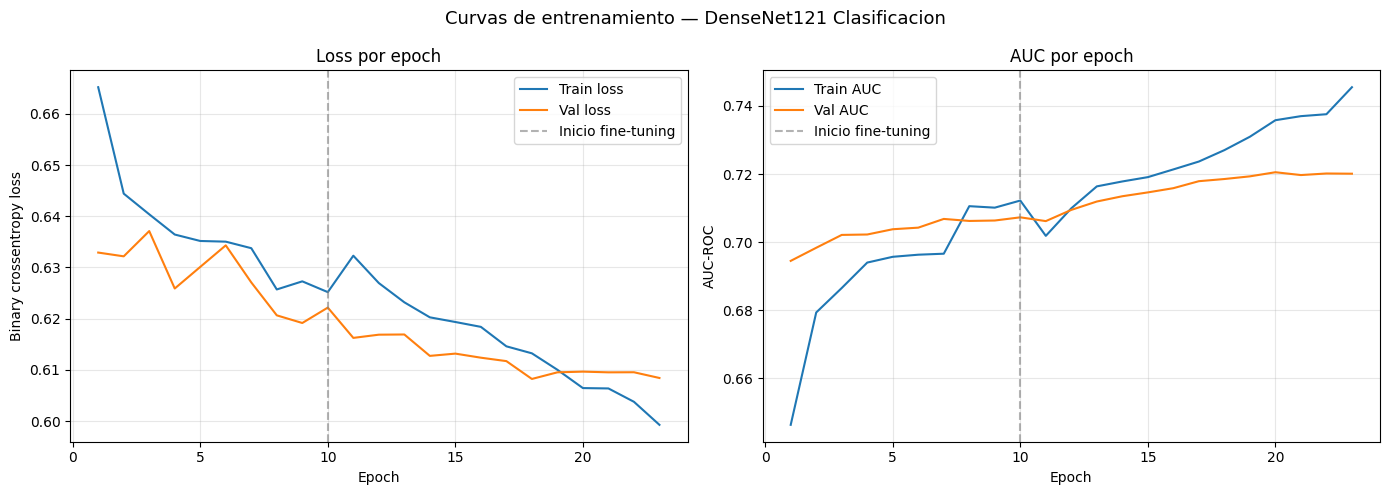

In [ ]:
def graficar_historia(historia_f1, historia_f2):
    """
    Combina las historias de las dos fases y grafica loss y AUC por epoch.
    Una linea vertical marca el fin de la Fase 1 y el inicio del fine-tuning.
    """
    # Combinar las metricas de ambas fases
    loss_train = historia_f1.history["loss"]     + historia_f2.history["loss"]
    loss_val   = historia_f1.history["val_loss"] + historia_f2.history["val_loss"]
    auc_train  = historia_f1.history["auc"]      + historia_f2.history["auc"]
    auc_val    = historia_f1.history["val_auc"]  + historia_f2.history["val_auc"]
    epochs_totales = range(1, len(loss_train) + 1)
    fin_fase1      = len(historia_f1.history["loss"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Grafica de Loss
    ax1.plot(epochs_totales, loss_train, label="Train loss")
    ax1.plot(epochs_totales, loss_val,   label="Val loss")
    ax1.axvline(x=fin_fase1, color="gray", linestyle="--", alpha=0.6, label="Inicio fine-tuning")
    ax1.set_title("Loss por epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Binary crossentropy loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Grafica de AUC
    ax2.plot(epochs_totales, auc_train, label="Train AUC")
    ax2.plot(epochs_totales, auc_val,   label="Val AUC")
    ax2.axvline(x=fin_fase1, color="gray", linestyle="--", alpha=0.6, label="Inicio fine-tuning")
    ax2.set_title("AUC por epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("AUC-ROC")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle("Curvas de entrenamiento — DenseNet121 Clasificacion", fontsize=13)
    plt.tight_layout()

    # Guardar la grafica en Drive
    ruta_grafica = ruta_checkpoints / "curvas_entrenamiento_clasificacion.png"
    plt.savefig(str(ruta_grafica), dpi=150, bbox_inches="tight")
    print(f"Grafica guardada en: {ruta_grafica}")
    plt.show()

graficar_historia(historia_fase1, historia_fase2)

## Celda 15 — Evaluacion en test del NIH

Cargamos el mejor modelo guardado (el checkpoint, no el del ultimo epoch) y lo
evaluamos en el conjunto de test del NIH que el modelo nunca vio durante el entrenamiento.

Las metricas que reportamos:
- Loss: valor de la funcion de costo
- Accuracy: porcentaje de predicciones correctas
- AUC-ROC: Area Under the Curve de la curva ROC. Mide que tan bien el modelo
  separa las dos clases independientemente del umbral de decision.
  Valor de 0.5 = aleatorio, 1.0 = perfecto. CheXNet reporto ~0.84 en promedio.

In [13]:
from tensorflow.keras.models import load_model

# Cargar el mejor modelo guardado por el checkpoint
print(f"Cargando mejor modelo desde: {ruta_mejor_modelo}")
mejor_modelo = load_model(ruta_mejor_modelo)

# Evaluar en el conjunto de test del NIH
print("\nEvaluacion en test NIH (patient-level split):")
resultados_nih = mejor_modelo.evaluate(flujo_test_nih, verbose=1)
nombres_metricas = mejor_modelo.metrics_names

for nombre, valor in zip(nombres_metricas, resultados_nih):
    print(f"  {nombre}: {valor:.4f}")

# Evaluacion en el conjunto de test del Chest X-Ray (validacion externa)
print("\nEvaluacion en test Chest X-Ray (validacion externa):")
resultados_chest = mejor_modelo.evaluate(flujo_chest_test, verbose=1)

for nombre, valor in zip(nombres_metricas, resultados_chest):
    print(f"  {nombre}: {valor:.4f}")

print()
print("Nota: el modelo fue entrenado con NIH. El rendimiento en Chest X-Ray")
print("refleja la capacidad de generalizacion a un dataset diferente.")

Cargando mejor modelo desde: /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion.h5



Evaluacion en test NIH (patient-level split):
637/637 ━━━━━━━━━━━━━━━━━━━━ 69s 75ms/step - accuracy: 0.6874 - auc: 0.7303 - loss: 0.6016
  loss: 0.6016
  compile_metrics: 0.6874

Evaluacion en test Chest X-Ray (validacion externa):
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.5513 - auc: 0.8376 - loss: 0.6588
  loss: 0.6588
  compile_metrics: 0.5513

Nota: el modelo fue entrenado con NIH. El rendimiento en Chest X-Ray
refleja la capacidad de generalizacion a un dataset diferente.


## Celda 16 — Matriz de confusion y metricas clinicas

La celda anterior reporto AUC y accuracy, que son metricas globales. Esta celda
profundiza en el rendimiento del modelo con metricas mas interpretables en
contexto medico.

La matriz de confusion desglosa las predicciones en cuatro categorias:
- Verdaderos positivos (TP): anomalias correctamente detectadas
- Verdaderos negativos (TN): casos normales correctamente identificados
- Falsos positivos (FP): normales clasificados erroneamente como anomalos
- Falsos negativos (FN): anomalias que el modelo no detecto

De estas cuatro categorias se derivan dos metricas clave en diagnostico:
- Sensibilidad: de todos los pacientes anomalos reales, que fraccion detecto el modelo.
  En medicina es critica porque un falso negativo (anomalia no detectada) es mas
  peligroso que un falso positivo.
- Especificidad: de todos los pacientes normales reales, que fraccion identifico
  correctamente. Un valor bajo genera alarmas innecesarias.

El umbral de decision usado es 0.5: si la probabilidad predicha es mayor a 0.5
el modelo clasifica como anomalia. Este umbral es ajustable segun el contexto
clinico deseado.

Generando predicciones en test NIH...
637/637 ━━━━━━━━━━━━━━━━━━━━ 46s 71ms/step

Matriz de confusion (test NIH):
  Verdaderos negativos (TN): 4,692  — normales correctamente identificados
  Falsos positivos    (FP): 1,246  — normales clasificados como anomalos
  Falsos negativos    (FN): 1,936  — anomalos clasificados como normales
  Verdaderos positivos (TP): 2,306  — anomalos correctamente identificados

Metricas clinicamente relevantes:
  Sensibilidad (Recall)  : 0.544  — capacidad de detectar anomalias reales
  Especificidad          : 0.790  — capacidad de identificar casos normales
  Precision              : 0.649  — confiabilidad cuando predice anomalia
  F1-Score               : 0.592  — balance entre sensibilidad y precision

Matriz guardada en: /content/drive/MyDrive/Vena/checkpoints/matriz_confusion_clasificacion.png


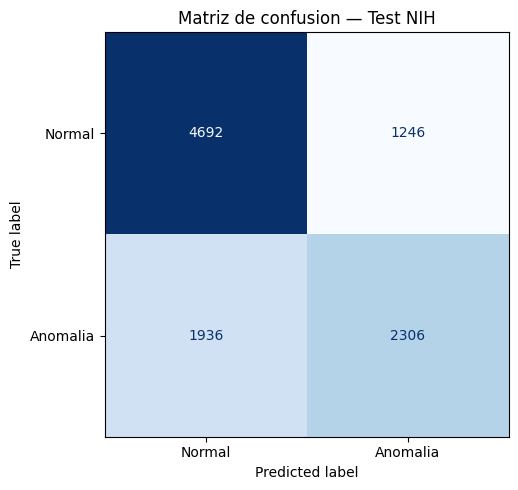


--- Validacion externa: Chest X-Ray ---
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step
  Sensibilidad : 0.295
  Especificidad: 0.979

              precision    recall  f1-score   support

      Normal       0.45      0.98      0.62       234
    Anomalia       0.96      0.29      0.45       390

    accuracy                           0.55       624
   macro avg       0.71      0.64      0.54       624
weighted avg       0.77      0.55      0.51       624



In [15]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Generar predicciones sobre el test NIH
# El modelo devuelve probabilidades entre 0 y 1
# Necesitamos recorrer el generador completo para obtener todas las predicciones
print("Generando predicciones en test NIH...")
flujo_test_nih.reset()  # reiniciar el generador al inicio

probabilidades = mejor_modelo.predict(flujo_test_nih, verbose=1)

# El generador puede producir algunos batches extra para completar
# el ultimo batch — recortar al numero real de imagenes
probabilidades = probabilidades[:len(df_test_nih)]

# Convertir probabilidades a etiquetas binarias con umbral 0.5
# Si prob >= 0.5 el modelo predice "anomalia" (1), si no "normal" (0)
etiquetas_reales     = df_test_nih["tiene_anomalia"].values
etiquetas_predichas  = (probabilidades.flatten() >= 0.5).astype(int)

# --- Matriz de confusion ---
# Filas = etiqueta real, Columnas = etiqueta predicha
# TN FP
# FN TP
cm = confusion_matrix(etiquetas_reales, etiquetas_predichas)
tn, fp, fn, tp = cm.ravel()

print(f"\nMatriz de confusion (test NIH):")
print(f"  Verdaderos negativos (TN): {tn:,}  — normales correctamente identificados")
print(f"  Falsos positivos    (FP): {fp:,}  — normales clasificados como anomalos")
print(f"  Falsos negativos    (FN): {fn:,}  — anomalos clasificados como normales")
print(f"  Verdaderos positivos (TP): {tp:,}  — anomalos correctamente identificados")

# --- Metricas clinicamente relevantes ---
sensibilidad  = tp / (tp + fn)   # de todos los anomalos reales, cuantos detecto
especificidad = tn / (tn + fp)   # de todos los normales reales, cuantos detecto
precision     = tp / (tp + fp)   # de los que predijo como anomalos, cuantos lo eran
f1            = 2 * (precision * sensibilidad) / (precision + sensibilidad)

print(f"\nMetricas clinicamente relevantes:")
print(f"  Sensibilidad (Recall)  : {sensibilidad:.3f}  — capacidad de detectar anomalias reales")
print(f"  Especificidad          : {especificidad:.3f}  — capacidad de identificar casos normales")
print(f"  Precision              : {precision:.3f}  — confiabilidad cuando predice anomalia")
print(f"  F1-Score               : {f1:.3f}  — balance entre sensibilidad y precision")

# --- Visualizacion de la matriz de confusion ---
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomalia"]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusion — Test NIH", fontsize=12)
plt.tight_layout()

ruta_cm = ruta_checkpoints / "matriz_confusion_clasificacion.png"
plt.savefig(str(ruta_cm), dpi=150, bbox_inches="tight")
print(f"\nMatriz guardada en: {ruta_cm}")
plt.show()

# --- Repetir para Chest X-Ray (validacion externa) ---
print("\n--- Validacion externa: Chest X-Ray ---")
flujo_chest_test.reset()
probabilidades_chest = mejor_modelo.predict(flujo_chest_test, verbose=1)
probabilidades_chest = probabilidades_chest[:len(flujo_chest_test.filenames)]

etiquetas_reales_chest   = flujo_chest_test.labels
etiquetas_predichas_chest = (probabilidades_chest.flatten() >= 0.5).astype(int)

cm_chest = confusion_matrix(etiquetas_reales_chest, etiquetas_predichas_chest)
tn_c, fp_c, fn_c, tp_c = cm_chest.ravel()

sensibilidad_chest  = tp_c / (tp_c + fn_c)
especificidad_chest = tn_c / (tn_c + fp_c)

print(f"  Sensibilidad : {sensibilidad_chest:.3f}")
print(f"  Especificidad: {especificidad_chest:.3f}")
print(f"\n{classification_report(etiquetas_reales_chest, etiquetas_predichas_chest, target_names=['Normal', 'Anomalia'])}")

## Celda 17 — Guardar el backbone por separado

Ademas del modelo completo (backbone + cabeza de clasificacion) que ya guardo el
checkpoint, necesitamos guardar el backbone solo para reutilizarlo en los notebooks
siguientes.

El notebook 03 (regresion de edad) cargara este backbone y le pondra una cabeza
diferente con una neurona lineal.

El notebook 04 (clustering) cargara este backbone y usara la salida de la capa
GlobalAveragePooling2D como vector de embedding para cada imagen.

Guardar el backbone por separado evita que los notebooks siguientes tengan que
cargar y luego desmantelar el modelo completo de clasificacion.

In [ ]:
from tensorflow.keras.models import Model

# El backbone no existe como sublayer nombrado "densenet121" porque
# al construir el modelo sus capas se integraron directamente.
# Lo reconstruimos usando la capa de entrada y la ultima capa
# del DenseNet antes de nuestra cabeza personalizada.
#
# La cabeza que agregamos fue: GlobalAveragePooling2D -> Dense(256) -> Dropout -> Dense(1)
# Entonces la ultima capa del backbone es la que va ANTES del GlobalAveragePooling2D.
# En DenseNet121 esa capa se llama "bn" (batch normalization final).

# Identificar la capa de salida del backbone
# Es la capa justo antes de nuestro GlobalAveragePooling2D
nombre_ultima_capa_backbone = "bn"  # ultima capa de DenseNet121 antes del pooling

try:
    capa_salida_backbone = mejor_modelo.get_layer(nombre_ultima_capa_backbone)
    print(f"Capa de salida del backbone encontrada: {capa_salida_backbone.name}")
except ValueError:
    # Si el nombre no coincide, buscarla por posicion
    # GlobalAveragePooling2D es la primera capa de nuestra cabeza
    nombres_capas = [l.name for l in mejor_modelo.layers]
    idx_pooling = next(
        i for i, n in enumerate(nombres_capas)
        if "global_average" in n
    )
    capa_salida_backbone = mejor_modelo.layers[idx_pooling - 1]
    print(f"Capa de salida del backbone encontrada por posicion: {capa_salida_backbone.name}")

# Construir el backbone como un Model independiente:
# misma entrada que el modelo completo, salida en la ultima capa del DenseNet
backbone_entrenado = Model(
    inputs=mejor_modelo.input,
    outputs=capa_salida_backbone.output,
    name="backbone_densenet121"
)

print(f"Backbone reconstruido correctamente.")
print(f"  Entrada : {backbone_entrenado.input_shape}")
print(f"  Salida  : {backbone_entrenado.output_shape}")
print(f"  Capas   : {len(backbone_entrenado.layers)}")

# Guardar el backbone reconstruido
ruta_backbone = str(ruta_checkpoints / "backbone_densenet121.h5")
backbone_entrenado.save(ruta_backbone)

print(f"\nBackbone guardado en: {ruta_backbone}")
print()
print("Archivos generados por este notebook:")
for archivo in ruta_checkpoints.iterdir():
    tamano_mb = archivo.stat().st_size / (1024 * 1024)
    print(f"  {archivo.name} ({tamano_mb:.1f} MB)")

Capa de salida del backbone encontrada: bn
Backbone reconstruido correctamente.
  Entrada : (None, 224, 224, 3)
  Salida  : (None, 7, 7, 1024)
  Capas   : 426

Backbone guardado en: /content/drive/MyDrive/Vena/checkpoints/backbone_densenet121.h5

Archivos generados por este notebook:
  mejor_modelo_clasificacion.h5 (39.4 MB)
  curvas_entrenamiento_clasificacion.png (0.1 MB)
  backbone_densenet121.h5 (28.1 MB)
